# Optimal cutoff value

This notebook explores a class of decision problems where options arrive sequentially and each must be accepted or rejected immediately, without the possibility of going back. The core problem/difficulty is that you do not know future options, but delaying too long risks missing the best one.

So the central question is:
When should you stop observing and start selecting?

A simple and famous problem like this is the is Secretary Problem, where the goal is to choose the single best candidate from a sequence under these constraints. The well-known result is that the optimal strategy is to observe and reject roughly the first 37% of options, and then select the next one that is better than all previous ones. Here this result will be derived and illustrated step by step.

## Setup

For that the notebook only needs a few basic tools:

- `random` to generate many random candidate orders
- `math` for the benchmark value $1/e$
- `matplotlib` to visualize how performance changes with the cutoff

So the overall structure is simple: **simulate the strategy many times, compare different cutoff values, and then check the result against the theoretical formula**.

In [228]:
import random
import math
import matplotlib.pyplot as plt

## Parameters of the experiment

The experiment is fixed to a candidate pool of size 100 and a large number of repetitions.

That is enough to make the Monte Carlo estimate reasonably stable without making the notebook unnecessarily heavy. The exact numbers are not the main point. What matters is the pattern: as the cutoff changes, the success probability rises, peaks around the classical threshold, and then falls again.


In [229]:
N_CANDIDATES = 100      # size of candidate pool per trial
N_SIMULATIONS = 10000   # Monte Carlo repetitions

## Core decision rule

Now the core of this notebook: This function encodes the actual "look, then leap" strategy.

The logic is:

1. **Look phase:** reject the first `cutoff` candidates and only use them to set a benchmark.
2. **Leap phase:** after that, accept the first candidate who beats everything seen so far.
3. **Fallback:** if nobody beats the benchmark, take the last candidate.

Each simulation and every theoretical comparison is built around this exact rule. The code is intentionally compact since the interesting part is not implementation complexity, but the decision principle behind it.


In [230]:
def secretary_trial(candidates: list[int], cutoff: int) -> bool:
    n = len(candidates) # best candidate is n, worst is 1
    # edge case
    if cutoff == 0:
        return candidates[0] == n

    # Look phase: record the best seen in the cutoff section
    best_in_look = max(candidates[:cutoff])

    # Leap phase: pick first that beats the look-phase best
    for c in candidates[cutoff:]:
        if c > best_in_look:
            return c == n  # true if found candidate is best overall

    # Never found one -> take last candidate
    return candidates[-1] == n # true if last candidate is best

## First empirical check at 37%

Before scanning all possible cutoffs, the we test one concrete choice: `k = 37` out of 100.

This is not arbitrary. The classical result says the optimal cutoff should be close to $n/e$, which for 100 candidates is about 36.8. So this cell is a quick sanity check: if the simulations are behaving as expected, the success rate here should already look close to the theoretical optimum.


In [231]:
pool = list(range(1, N_CANDIDATES + 1))  # 1 = worst, N = best

successes = 0
for _ in range(N_SIMULATIONS):
    random.shuffle(pool)
    if secretary_trial(pool, 37):
        successes += 1

empirical_rate = successes / N_SIMULATIONS
print(f"Empirical success rate : {empirical_rate:.4f}")

Empirical success rate : 0.3718


We see that the succes rate is as expected around 0.37 or 37%.

## Sweep over all cutoff values

Now let's not just test one cutoff but evaluate the whole range from 0 to 100.

That matters because it turns the argument from a claim into evidence:

- very small cutoffs fail because the benchmark is too weak,
- very large cutoffs fail because too many candidates are thrown away,
- somewhere in the middle the trade-off is best.

In [232]:
fractions = [k / N_CANDIDATES for k in range(0, N_CANDIDATES + 1)] # every possible cutoff fraction
success_rates = []

# for each possible cutoff k, run some simulations and record the success rate
for k in range(0, N_CANDIDATES + 1):
    wins = sum(
        secretary_trial(random.sample(pool, N_CANDIDATES), k)
        for _ in range(N_SIMULATIONS // 10)  # fewer reps for speed
    )
    success_rates.append(wins / (N_SIMULATIONS // 10))

best_k = max(range(len(success_rates)), key=lambda i: success_rates[i]) # find the index where that success rate is highest
print(f"Empirical best cutoff  : {best_k}/{N_CANDIDATES} = {best_k/N_CANDIDATES:.3f}")
print(f"Success rate at peak   : {success_rates[best_k]:.4f}")

Empirical best cutoff  : 33/100 = 0.330
Success rate at peak   : 0.3910


In order to understand the numbers more, we visualize the result:

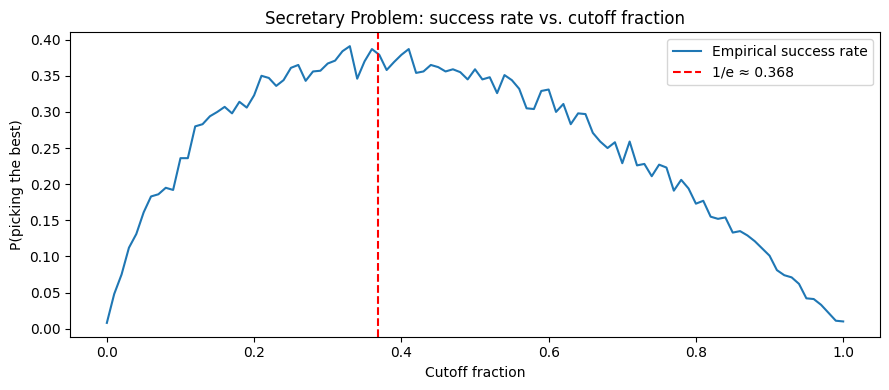

In [234]:
plt.figure(figsize=(9, 4))
plt.plot(fractions, success_rates, label="Empirical success rate")
plt.axvline(1 / math.e, color="red", linestyle="--", label=f"1/e ≈ {1/math.e:.3f}")
plt.xlabel("Cutoff fraction")
plt.ylabel("P(picking the best)")
plt.title("Secretary Problem: success rate vs. cutoff fraction")
plt.legend()
plt.tight_layout()
plt.show()

We see exactly, what we expected:
- If the cutoff is too small, you start selecting too early -> you lack information
- If the cutoff is too large, you skip too many candidates -> you likely miss the best one

The peak of the curve marks the optimal trade-off, which occurs at around 37%.
This is where the probability of choosing the best option is maximized.

## Exact theory behind the simulation

The final step is to move from simulation to the closed-form success probability.

This is important because Monte Carlo results are only approximations of the truth. The exact formula explains *why* the peak appears where it does and lets you compare the empirical curve against the mathematically derived result. 

In the next code part, we explicitly compute this probability using the formula

\[
P(r) = \sum_{k=r+1}^{n} \frac{1}{n} \cdot \frac{r}{k-1}
\]

where:
- \( n \) is the total number of candidates  
- \( r \) is the cutoff (number of candidates we skip)  
- \( k \) represents the position of the best candidate  

The logic directly mirrors the implementation:
- We iterate over all possible positions \( k \) where the best candidate could appear  
- For each \( k > r \), we compute the probability that:
  1. the best candidate is at position \( k \) (\( \frac{1}{n} \))  
  2. the best candidate among the first \( k-1 \) lies within the first \( r \) observations (\( \frac{r}{k-1} \))  

By summing over all valid \( k \), we obtain the exact success probability for a given cutoff \( r \).

In [233]:
# what is the exact theoretical probability of picking the best?
def exact_probability(n: int, k: int) -> float:
    if k == 0:
        return 1 / n  # pure random guess
    total = sum(1 / (i - 1) for i in range(k + 1, n + 1))
    return (k / n) * total

print(f"n = {N_CANDIDATES}")
print(f"{'Cutoff k':>10} {'Fraction':>10} {'P(success)':>12}")
for k in [1, 10, 20, 30, 37, 40, 50, 60, 70]:
    p = exact_probability(N_CANDIDATES, k)
    print(f"{k:>10}  {k/N_CANDIDATES:>9.3f}  {p:>12.6f}")

p_optimal = exact_probability(N_CANDIDATES, 37)
print(f"\nAt cutoff (k=37): P = {p_optimal:.6f}")
print(f"Theoretical limit (1/e)    : P = {1/math.e:.6f}")

n = 100
  Cutoff k   Fraction   P(success)
         1      0.010      0.051774
        10      0.100      0.234841
        20      0.200      0.325928
        30      0.300      0.364717
        37      0.370      0.371043
        40      0.400      0.369534
        50      0.500      0.349086
        60      0.600      0.308504
        70      0.700      0.251179

At cutoff (k=37): P = 0.371043
Theoretical limit (1/e)    : P = 0.367879


### Conclusion

The results show a clear peak in success probability around a cutoff of \( k \approx 37 \) (i.e., ~37% of the candidates). At this point, the probability of selecting the best option is maximized at approximately 0.371.

This closely matches the theoretical limit of \( \frac{1}{e} \approx 0.3679 \), with only a small deviation due to the finite sample size (\( n = 100 \)). As \( n \) increases, this difference would shrink and converge to the theoretical value.

The table also highlights the trade-off:
- Small cutoffs (e.g., 10%) underperform because not enough information is gathered  
- Large cutoffs (e.g., 50%+) underperform because too many candidates are skipped  

Overall, both the analytical computation and the earlier simulation point to the same result:  
**the optimal strategy is to reject roughly the first 37% of options and then select the next best**.